# Diabetes Gradient Boosting 회귀

## 개요
- Gradient Boosting Regressor로 당뇨병 진행도 예측
- 잔차(Residual) 기반 순차적 학습
- GridSearchCV로 최적화

## 주요 단계
1. 데이터 로드 및 분리
2. Gradient Boosting Regressor 설정
3. GridSearchCV 최적화
4. 회귀 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 1. 데이터 로드

**Diabetes 데이터셋**
- 442개 샘플, 10개 피처
- 당뇨병 진행도 예측 (회귀 문제)

In [2]:
# 데이터 로드
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(diabetes.feature_names)}")
print(f"\n타겟 통계:")
print(f"  평균: {y.mean():.2f}")
print(f"  범위: {y.min():.0f} ~ {y.max():.0f}")

데이터 크기: (442, 10)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

타겟 통계:
  평균: 152.13
  범위: 25 ~ 346


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

기술 통계:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072

**학습/테스트 데이터 분리**

In [4]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


## 2. Gradient Boosting Regressor

**Gradient Boosting 회귀 원리**
1. 초기 예측: 평균값
2. 잔차 계산: 실제값 - 예측값
3. 잔차 예측 트리 추가
4. 예측 업데이트: 이전 + learning_rate × 새 트리
5. 반복하여 MSE 최소화

**특징**
- 손실 함수: MSE, MAE, Huber 등
- Gradient Descent: 기울기 방향
- 순차적: 이전 오류 보정
- 얕은 트리: max_depth=3~5

**하이퍼파라미터**
- n_estimators: 트리 개수
- learning_rate: 학습률 (0.01~0.1)
- max_depth: 트리 깊이 (3~5)
- min_samples_split: 분할 최소 샘플
- subsample: 샘플링 비율 (과적합 방지)

**모델 설정**

In [5]:
# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(random_state=42)

print("Gradient Boosting Regressor 생성")
print(f"기본 설정: n_estimators=100, learning_rate=0.1, max_depth=3")

Gradient Boosting Regressor 생성
기본 설정: n_estimators=100, learning_rate=0.1, max_depth=3


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [100, 200, 300]
- learning_rate: [0.01, 0.05, 0.1]
- max_depth: [3, 4]
- min_samples_split: [2, 5]

**튜닝 전략**
- learning_rate 낮게 + n_estimators 많이
- max_depth는 3~5 권장

In [6]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1]
  max_depth: [3, 4]
  min_samples_split: [2, 5]

총 조합 수: 36개


In [7]:
# GridSearchCV
print("\nTuning Gradient Boosting Regressor...")
print("(교차검증 수행 중... 시간이 소요됩니다)\n")

grid_reg = GridSearchCV(
    gb_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning Gradient Boosting Regressor...
(교차검증 수행 중... 시간이 소요됩니다)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [8]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): 0.3950

Best Parameters:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 2
  n_estimators: 100


**GridSearchCV 상위 결과**

In [9]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_min_samples_split',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  param_max_depth  param_min_samples_split  mean_test_score  std_test_score
                100                 0.05                3                        2         0.394970        0.076742
                100                 0.05                3                        5         0.394906        0.073975
                300                 0.01                3                        5         0.391062        0.074824
                300                 0.01                3                        2         0.390918        0.075609
                200                 0.01                3                        2         0.388460        0.061035


## 5. 테스트 데이터 평가

**회귀 성능 평가**

In [10]:
# 테스트 데이터 예측
y_pred = best_reg.predict(X_test)

# 평가 지표
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("\n[테스트 성능]")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")


[테스트 성능]
Test RMSE: 52.7695
Test R2 Score: 0.4744
Test MAE: 43.1792


**예측 결과 시각화**

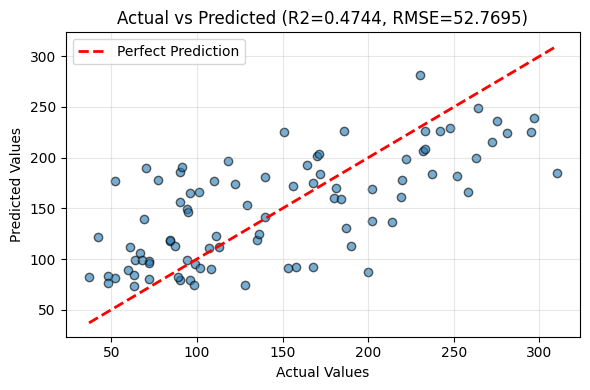

In [18]:
# 실제값 vs 예측값
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted (R2={r2:.4f}, RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**Gradient Boosting 피처 중요도**
- MSE 감소에 대한 기여도
- 각 트리의 분할 정보 집계
- 높은 값: 예측에 중요한 피처

In [13]:
# 피처 중요도 추출
importances = best_reg.feature_importances_
feature_names = diabetes.feature_names
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': np.array(feature_names)[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
    bmi    0.416591
     s5    0.262049
     bp    0.086219
     s2    0.047812
     s6    0.040736
    age    0.040161
     s3    0.036297
     s1    0.031987
     s4    0.026558
    sex    0.011590


**피처 중요도 시각화**

/tmp/ipython-input-102686428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')


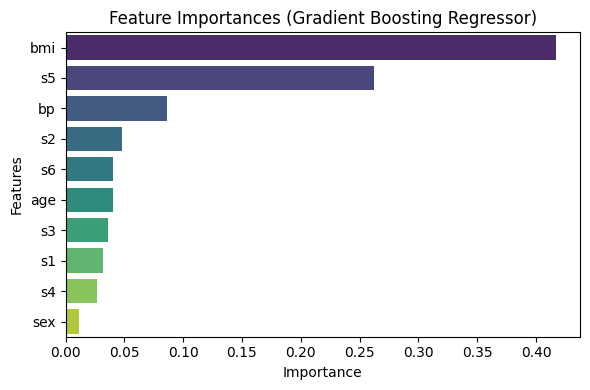

In [19]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')
plt.title("Feature Importances (Gradient Boosting Regressor)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. 기본 파라미터 vs 최적 파라미터

**GridSearch 효과 검증**

In [21]:
# 기본 파라미터로 학습
gb_default = GradientBoostingRegressor(random_state=42)
gb_default.fit(X_train, y_train)
y_pred_default = gb_default.predict(X_test)

rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
r2_default = r2_score(y_test, y_pred_default)

# 비교
print("\nGridSearch 효과:")
print(f"기본 파라미터:")
print(f"  RMSE = {rmse_default:.4f}, R2 = {r2_default:.4f}")
print(f"\n최적 파라미터:")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"\nRMSE 개선: {rmse_default - rmse:+.4f}")
print(f"R2 개선: {r2 - r2_default:+.4f}")


GridSearch 효과:
기본 파라미터:
  RMSE = 53.8371, R2 = 0.4529

최적 파라미터:
  RMSE = 52.7695, R2 = 0.4744

RMSE 개선: +1.0676
R2 개선: +0.0215
